#### STEP 1: Import Libraries

In [20]:

# STEP 1: Import Libraries

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#### STEP 2: Define Project Paths

In [21]:

# STEP 2: Project Paths

PROJECT_DIR = Path.cwd().parent

MODEL_PATH = PROJECT_DIR / "models" / "tomato_disease_classifier.keras"

HISTORY_PATH = PROJECT_DIR / "models" / "training_history.csv"

TEST_DIR = PROJECT_DIR / "dataset" / "test"

#### STEP 3: Load the Model

In [22]:

# STEP 3: Load Saved Model

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


#### STEP 4: Load the Test Dataset

In [23]:

# STEP 4: Load Test Dataset

IMG_SIZE = (224,224)

BATCH_SIZE = 32

test_dataset = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)

class_names = test_dataset.class_names

print(class_names)

Found 259 files belonging to 2 classes.
['Tomato_Early_blight', 'Tomato_healthy']


#### STEP 5: Evaluate the Model

In [24]:

# STEP 5: Evaluate Model

test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")

print(f"Test Accuracy: {test_accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 559ms/step - accuracy: 0.9923 - loss: 0.0266
Test Loss: 0.0266
Test Accuracy: 0.9923


#### STEP 6: Generate Predictions

In [25]:

# STEP 6: Make Predictions


probabilities = model.predict(test_dataset)

predictions = np.argmax(probabilities, axis=1)

true_labels = np.concatenate(

    [labels.numpy() for images, labels in test_dataset]

)

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 612ms/step


#### STEP 7: Create Prediction Table

In [26]:

# STEP 7: Prediction Table

prediction_df = pd.DataFrame({

    "True Label": true_labels,

    "Predicted": predictions,

    "Confidence": np.max(probabilities, axis=1)

})

prediction_df.head(20)

,True Label,Predicted,Confidence
0,0,0,0.999984
1,0,0,1.000000
2,0,0,1.000000
3,0,0,0.999990
4,0,0,0.999997
5,0,0,0.999541
6,0,0,0.999533
7,0,0,0.999985
8,0,0,0.999626
9,0,0,0.999984


#### STEP 8: Confusion Matrix

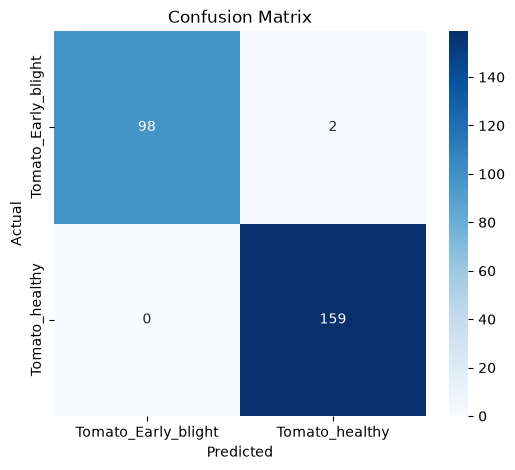

In [27]:

# STEP 8: Confusion Matrix

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

#### STEP 9: Classification Metrics

In [28]:

# STEP 9: Evaluation Metrics


accuracy = accuracy_score(true_labels, predictions)

precision = precision_score(
    true_labels,
    predictions,
    average="weighted"
)

recall = recall_score(
    true_labels,
    predictions,
    average="weighted"
)

f1 = f1_score(
    true_labels,
    predictions,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9923
Precision: 0.9924
Recall   : 0.9923
F1 Score : 0.9923


#### STEP 10: Classification Report

In [29]:

# STEP 10: Classification Report


print(

    classification_report(

        true_labels,

        predictions,

        target_names=class_names

    )

)

                     precision    recall  f1-score   support

Tomato_Early_blight       1.00      0.98      0.99       100
     Tomato_healthy       0.99      1.00      0.99       159

           accuracy                           0.99       259
          macro avg       0.99      0.99      0.99       259
       weighted avg       0.99      0.99      0.99       259



#### STEP 11: False Positive Rate and False Negative Rate

In [30]:

# STEP 11: FPR and FNR

tn, fp, fn, tp = cm.ravel()

fnr = fn / (fn + tp)

fpr = fp / (fp + tn)

print(f"False Negative Rate: {fnr:.4f}")

print(f"False Positive Rate: {fpr:.4f}")

False Negative Rate: 0.0000
False Positive Rate: 0.0200


#### STEP 12: Plot Training History

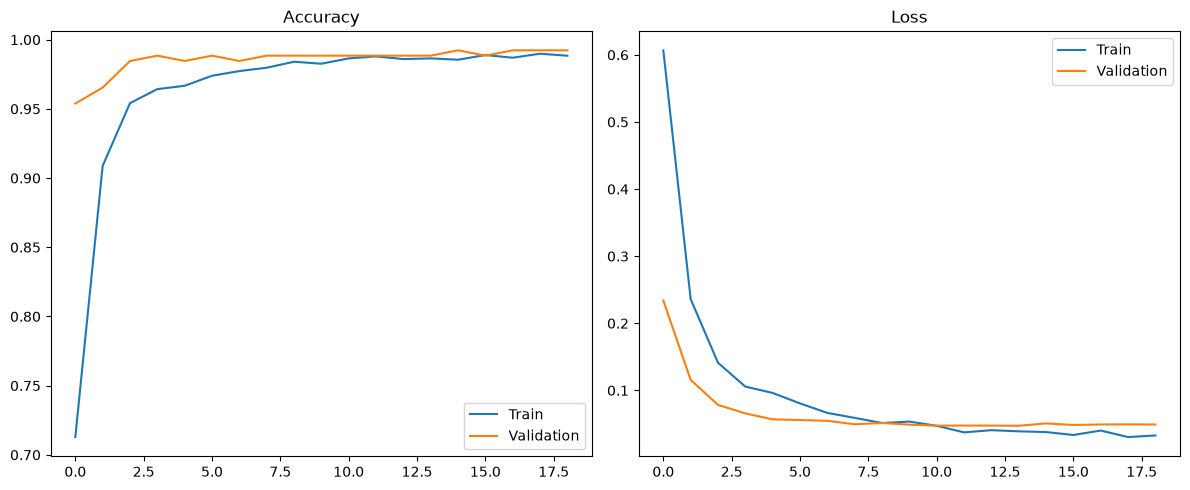

In [31]:

# STEP 12: Training Curves


history = pd.read_csv(HISTORY_PATH)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history["accuracy"])

plt.plot(history["val_accuracy"])

plt.title("Accuracy")

plt.legend(["Train","Validation"])

plt.subplot(1,2,2)

plt.plot(history["loss"])

plt.plot(history["val_loss"])

plt.title("Loss")

plt.legend(["Train","Validation"])

plt.tight_layout()

plt.show()

#### STEP 13: Display Sample Predictions

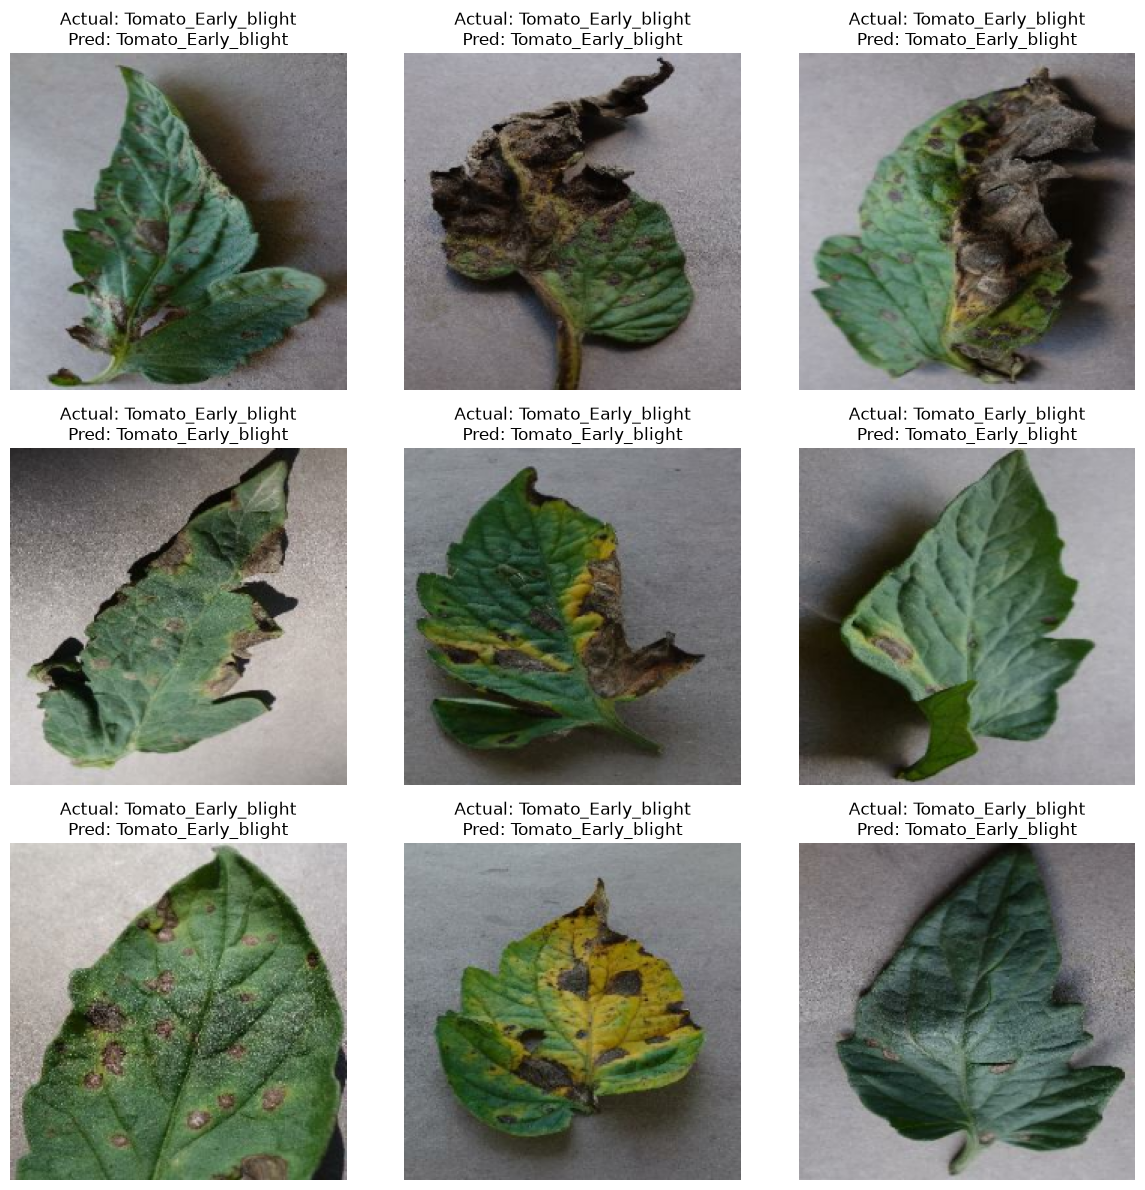

In [32]:

# STEP 13: Display Sample Predictions

plt.figure(figsize=(12,12))

for images, labels in test_dataset.take(1):

    probs = model.predict(images, verbose=0)

    preds = np.argmax(probs, axis=1)

    for i in range(min(9, len(images))):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(
            f"Actual: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}"
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

In [33]:
print(class_names)

['Tomato_Early_blight', 'Tomato_healthy']
